In [1]:
import subprocess, sys, torch

# RTX 5080 = Blackwell ארכיטקטורה - צריך CUDA 12.8 + PyTorch 2.7+
print(f'PyTorch נוכחי: {torch.__version__}')
print(f'CUDA נוכחי: {torch.version.cuda}')

if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

needs_update = (
    not torch.cuda.is_available() or
    'no kernel image' in '' or
    torch.version.cuda < '12.8'
)

print('\nמעדכן PyTorch ל-CUDA 12.8 עבור RTX 5080 (Blackwell)...')
subprocess.check_call([
    sys.executable, '-m', 'pip', 'install', '--upgrade',
    'torch', 'torchvision', 'torchaudio',
    '--index-url', 'https://download.pytorch.org/whl/cu128'
])
print('\nהתקנה הסתיימה! עכשיו תעשה Restart לקרנל ותריץ שוב מתא 1.')

PyTorch נוכחי: 2.11.0+cu128
CUDA נוכחי: 12.8
GPU: NVIDIA GeForce RTX 5080

מעדכן PyTorch ל-CUDA 12.8 עבור RTX 5080 (Blackwell)...

התקנה הסתיימה! עכשיו תעשה Restart לקרנל ותריץ שוב מתא 1.


In [2]:
# Cell 0 - התקנת PyTorch עם CUDA (להריץ רק פעם אחת)
# אם torch כבר מותקן עם CUDA - אפשר לדלג על התא הזה
import subprocess, sys

try:
    import torch
    if torch.cuda.is_available():
        print(f'CUDA כבר עובד! גרסה: {torch.version.cuda}')
        print('אפשר לדלג על התא הזה')
    else:
        print('PyTorch מותקן אבל בלי CUDA - מתקין מחדש...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install',
            'torch', 'torchvision', 'torchaudio',
            '--index-url', 'https://download.pytorch.org/whl/cu124'])
        print('סיים! עכשיו תעשה Restart לקרנל ותריץ שוב')
except ImportError:
    print('מתקין PyTorch עם CUDA...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install',
        'torch', 'torchvision', 'torchaudio',
        '--index-url', 'https://download.pytorch.org/whl/cu124'])
    print('סיים! עכשיו תעשה Restart לקרנל ותריץ שוב')

CUDA כבר עובד! גרסה: 12.8
אפשר לדלג על התא הזה


In [4]:
# Cell 1 - בדיקת GPU ויבוא ספריות
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models.video import mvit_v2_s, MViT_V2_S_Weights
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns

# בדיקת CUDA
print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
print(f'CUDA version: {torch.version.cuda}')

if not torch.cuda.is_available():
    raise RuntimeError('CUDA לא זמין! תריץ את התא הראשון להתקנת PyTorch עם CUDA')

device = torch.device('cuda')
print(f'\nGPU: {torch.cuda.get_device_name(0)}')
print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB')
print(f'\nהכל תקין - רץ על GPU!')

PyTorch version: 2.11.0+cu128
CUDA available: True
CUDA version: 12.8

GPU: NVIDIA GeForce RTX 5080
VRAM: 15.9 GB

הכל תקין - רץ על GPU!


In [5]:
import os
from sklearn.model_selection import train_test_split # <--- הוספנו את ספריית הפיצול

# הנתיב החדש שלך
base_path = r'C:\Users\User\Desktop\מיכאל\data'

train_dirs = [base_path]
# מחקנו את val_dirs ו-test_dirs כי עכשיו אנחנו מפצלים את train_dirs

violent_folders = {'Fight'}
normal_folders  = {'NonFight'}

def label_from_path(filepath):
    parts = set(filepath.replace('\\', '/').split('/'))
    if parts & violent_folders: return 1
    if parts & normal_folders: return 0
    return None

def scan_dirs(dir_list):
    files, labels = [], []
    for d in dir_list:
        if not os.path.exists(d): continue
        for root, _, filenames in os.walk(d):
            for filename in filenames:
                if filename.lower().endswith(('.avi', '.mp4', '.mov')):
                    label = label_from_path(os.path.join(root, filename))
                    if label is not None:
                        files.append(os.path.join(root, filename))
                        labels.append(label)
    return files, labels

# 1. קודם כל סורקים את כל הקבצים מהתיקייה
all_files, all_labels = scan_dirs(train_dirs)

print(f'נמצאו סך הכל {len(all_files)} סרטונים: {all_labels.count(1)} אלימות, {all_labels.count(0)} שגרה.')

# 2. פיצול ראשון: 80% לאימון (train), וה-20% הנותרים ילכו למשתנה זמני (temp)
train_files, temp_files, train_labels, temp_labels = train_test_split(
    all_files, all_labels, test_size=0.2, random_state=42, stratify=all_labels
)

# 3. פיצול שני: מה-20% הנותרים (temp), חצי לולידציה (val) וחצי לטסט (test)
val_files, test_files, val_labels, test_labels = train_test_split(
    temp_files, temp_labels, test_size=0.5, random_state=42, stratify=temp_labels
)

print(f'אחרי פיצול - Train: {len(train_files)} | Val: {len(val_files)} | Test: {len(test_files)}')

נמצאו סך הכל 4703 סרטונים: 2351 אלימות, 2352 שגרה.
אחרי פיצול - Train: 3762 | Val: 470 | Test: 471


In [6]:
# Cell 3 - Dataset test with 60% window
import os
import cv2
import torch
import random
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

NUM_FRAMES = 16  
IMG_SIZE   = 224
BATCH_SIZE = 4

MEAN = [0.45, 0.45, 0.45]
STD  = [0.225, 0.225, 0.225]

train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

def extract_frames(video_path, num_frames=NUM_FRAMES, augment_transform=None, is_train=False):
    frames = []
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total <= 0:
        cap.release()
        return None
    
    # === חלון זמן קבוע של 60% (3 שניות) ===
    window_size = int(total * 0.6) 
    
    if is_train and total > window_size:
        # באימון: חיתוך אקראי כדי למנוע שינון ולתפוס הכל
        max_start = total - window_size
        start_frame = random.randint(0, max_start)
    else:
        # בטסט/וולידציה: חיתוך אמצע (Center Crop) לבחינה הוגנת ויציבה
        if total > window_size:
            start_frame = (total - window_size) // 2
        else:
            start_frame = 0
            window_size = total
            
    remaining_frames = window_size
    skip = max(int(remaining_frames / num_frames), 1)
    # ============================================
    
    transform = augment_transform if augment_transform else val_transform
    for i in range(num_frames):
        cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame + (i * skip))
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = transform(frame)
        frames.append(frame)
    cap.release()
    
    while len(frames) < num_frames:
        frames.append(frames[-1] if frames else torch.zeros(3, IMG_SIZE, IMG_SIZE))
    frames = torch.stack(frames)
    frames = frames.permute(1, 0, 2, 3)
    return frames

class VideoDataset(Dataset):
    def __init__(self, files, labels, is_train=False):
        self.files     = files
        self.labels    = labels
        self.is_train  = is_train

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        t = train_transform if self.is_train else val_transform
        frames = extract_frames(self.files[idx], augment_transform=t, is_train=self.is_train)
        if frames is None:
            frames = torch.zeros(3, NUM_FRAMES, IMG_SIZE, IMG_SIZE)
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        return frames, label

train_dataset = VideoDataset(train_files, train_labels, is_train=True)
val_dataset   = VideoDataset(val_files,   val_labels,   is_train=False)
test_dataset  = VideoDataset(test_files,  test_labels,  is_train=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f'Train batches: {len(train_loader)}')
print(f'Val batches:   {len(val_loader)}')
print(f'Test batches:  {len(test_loader)}')

Train batches: 941
Val batches:   118
Test batches:  118


In [7]:
# Cell 4 - בניית המודל MViT v2
class ViolenceDetectorMViT(nn.Module):
    def __init__(self, dropout=0.5):
        super(ViolenceDetectorMViT, self).__init__()

        weights = MViT_V2_S_Weights.DEFAULT
        self.mvit = mvit_v2_s(weights=weights)

        # הקפאת רוב השכבות - נאמן רק את השכבות האחרונות
        for name, param in self.mvit.named_parameters():
            if 'blocks.14' not in name and 'blocks.15' not in name and 'head' not in name:
                param.requires_grad = False

        # החלפת ראש הסיווג ל-Binary
        in_features = self.mvit.head[1].in_features
        self.mvit.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.mvit(x).squeeze(1)

model = ViolenceDetectorMViT().to(device)
print('MViT v2 נטען על GPU בהצלחה!')
print(f'Device: {next(model.parameters()).device}')
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'פרמטרים לאימון: {trainable:,} / {total:,}')

MViT v2 נטען על GPU בהצלחה!
Device: cuda:0
פרמטרים לאימון: 13,810,305 / 34,427,265


In [ ]:
# Cell 5 - הגדרת אימון והמשך למידה (Fine-Tuning)
import os
import shutil
from datetime import datetime

EPOCHS = 10 # 10 סיבובים אמורים להספיק כי המודל כבר מאומן ברובו
MAX_TRAIN_STEPS = len(train_loader) 
MAX_VAL_STEPS   = len(val_loader)   

# הנתיב לשמירת המודל (וממנו גם נטען)
save_dir = r'C:\Users\User\Desktop\מיכאל\trained_model_mvit'
os.makedirs(save_dir, exist_ok=True)

# --- כאן מתבצעת טעינת המשקולות הקיימות ---
model_path = os.path.join(save_dir, 'best_model_mvit.pth')
if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path))
    print(f"✅ המוח הקיים נטען מ-{model_path}!\nממשיך ללמוד מהנקודה שבה עצרנו.")
    
    # --- הגיבוי האוטומטי שהוספנו ---
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    backup_filename = f'best_model_mvit_backup_before_run_{timestamp}.pth'
    backup_path = os.path.join(save_dir, backup_filename)
    shutil.copy2(model_path, backup_path)
    print(f"💾 גיבוי אוטומטי של משקולות הפתיחה נשמר כ: {backup_filename}")
else:
    print("⚠️ לא נמצא קובץ משקולות קודם, מתחיל אימון מאפס.")
# ----------------------------------------

# קצב למידה (LR) קטן יותר כי אנחנו עושים "כוונון עדין" ולא למידה מאפס
LR = 1e-4 

criterion  = nn.BCELoss()

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=1e-5
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

print(f'\nEpochs: {EPOCHS} | LR: {LR}')
print(f'Train steps per epoch: {MAX_TRAIN_STEPS} באצ\'ים')
print(f'Val steps per epoch:   {MAX_VAL_STEPS} באצ\'ים')
print(f'שמירה ב: {save_dir}')

⚠️ לא נמצא קובץ משקולות קודם, מתחיל אימון מאפס.

Epochs: 25 | LR: 0.0001
Train steps per epoch: 861 באצ'ים
Val steps per epoch:   108 באצ'ים
שמירה ב: C:\Users\User\Desktop\מיכאל\trained_model_mvit


In [8]:
# Cell 5 - הגדרת אימון והמשך למידה (Fine-Tuning) test with 60 % window
import os
import shutil
from datetime import datetime
import torch.optim as optim
import torch.nn as nn

EPOCHS = 25 # מנצלים את ה-GPU המהיר כדי לקבל 96.5% ודאות
MAX_TRAIN_STEPS = len(train_loader) 
MAX_VAL_STEPS   = len(val_loader)   

save_dir = r'C:\Users\User\Desktop\מיכאל\trained_model_mvit'
os.makedirs(save_dir, exist_ok=True)

model_path = os.path.join(save_dir, 'best_model_mvit.pth')
if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path))
    print("✅ המוח הקיים נטען ממשיכים אימון מנקודה קודמת (Fine-Tuning)")
else:
    print("⚠️ לא נמצא קובץ משקולות קודם, מתחיל אימון מאפס.")

# קצב למידה (LR) נמוך כי אנחנו משפרים מוח קיים
LR = 1e-5

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(
    model.parameters(), 
    lr=LR, 
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

print(f'\nEpochs: {EPOCHS} | LR: {LR}')

✅ המוח הקיים נטען ממשיכים אימון מנקודה קודמת (Fine-Tuning)

Epochs: 25 | LR: 1e-05


In [73]:
# Cell 6 - לולאת האימון
import os
import torch
from datetime import datetime # <--- שינוי 1: הוספת ספריית תאריכים וזמנים

best_val_f1 = 0.0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}

def calc_f1(preds, labels):
    tp = ((preds == 1) & (labels == 1)).sum().item()
    fp = ((preds == 1) & (labels == 0)).sum().item()
    fn = ((preds == 0) & (labels == 1)).sum().item()
    precision = tp / (tp + fp + 1e-8)
    recall    = tp / (tp + fn + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)
    return f1, precision, recall

for epoch in range(EPOCHS):
    # --- TRAIN ---
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0
    train_iter = iter(train_loader)

    for batch_idx in range(MAX_TRAIN_STEPS):
        try:
            frames, labels = next(train_iter)
        except StopIteration:
            break

        frames = frames.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(frames)
        loss    = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss    += loss.item()
        predicted      = (outputs > 0.5).float()
        train_correct += (predicted == labels).sum().item()
        train_total   += labels.size(0)

        # <--- שינוי 2: שינוי תנאי ההדפסה
        # הדפסה רק פעם אחת בסוף כל Epoch כדי למנוע את חיתוך הפלט
        if (batch_idx + 1) == MAX_TRAIN_STEPS:
            print(f'  Epoch {epoch+1} | Batch {batch_idx+1}/{MAX_TRAIN_STEPS} | Loss: {loss.item():.4f}')

    train_acc  = train_correct / train_total
    train_loss = train_loss / MAX_TRAIN_STEPS

    # --- VALIDATION ---
    model.eval()
    val_loss = 0
    all_preds, all_labels = [], []
    val_iter = iter(val_loader)

    with torch.no_grad():
        for _ in range(MAX_VAL_STEPS):
            try:
                frames, labels = next(val_iter)
            except StopIteration:
                break
            frames = frames.to(device)
            labels = labels.to(device)
            outputs   = model(frames)
            loss      = criterion(outputs, labels)
            val_loss += loss.item()
            predicted = (outputs > 0.5).float()
            all_preds.append(predicted)
            all_labels.append(labels)

    all_preds  = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    val_acc    = (all_preds == all_labels).float().mean().item()
    val_loss   = val_loss / MAX_VAL_STEPS
    val_f1, val_precision, val_recall = calc_f1(all_preds, all_labels)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    print(f'\nEpoch {epoch+1}/{EPOCHS}')
    print(f'  Train: Acc={train_acc:.4f} | Loss={train_loss:.4f}')
    print(f'  Val:   Acc={val_acc:.4f} | Loss={val_loss:.4f} | F1={val_f1:.4f} | Precision={val_precision:.4f} | Recall={val_recall:.4f}')

    # <--- שינוי 3: מנגנון השמירה הכפול למשקולות
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        
        # 1. שמירת הקובץ הרגיל תחת השם הקבוע (נדרס כל פעם)
        standard_path = os.path.join(save_dir, 'best_model_mvit.pth')
        torch.save(model.state_dict(), standard_path)
        
        # 2. יצירת עותק נוסף (גיבוי) עם תאריך, שעה וציון בשם הקובץ (לא נדרס לעולם)
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        backup_filename = f'best_model_mvit_{timestamp}_F1_{best_val_f1:.4f}.pth'
        backup_path = os.path.join(save_dir, backup_filename)
        torch.save(model.state_dict(), backup_path)
        
        print(f'  מודל חדש נשמר! F1={best_val_f1:.4f} (גיבוי נשמר כ: {backup_filename})')

    scheduler.step()

print(f'\nאימון הסתיים! F1 הטוב ביותר: {best_val_f1:.4f}')
print('לאימון מלא - שנה EPOCHS=20 ו-MAX_TRAIN_STEPS=20349')

# <--- שינוי 4: הוספת טבלת סיכום היסטוריית האימון
# --- הדפסת טבלת סיכום נקייה בסוף האימון לעקיפת החיתוך של המחברת ---
print("\n" + "="*50)
print("סיכום מהלך האימון (כל ה-Epochs):")
print("="*50)
for e in range(EPOCHS):
    v_f1  = history['val_f1'][e]
    v_acc = history['val_acc'][e]
    t_loss = history['train_loss'][e]
    print(f"Epoch {e+1:02d} | Train Loss: {t_loss:.4f} | Val Acc: {v_acc:.4f} | Val F1: {v_f1:.4f}")
print("="*50)

  Epoch 1 | Batch 941/941 | Loss: 0.3525

Epoch 1/25
  Train: Acc=0.9232 | Loss=0.5405
  Val:   Acc=0.9660 | Loss=0.5203 | F1=0.9662 | Precision=0.9582 | Recall=0.9745
  מודל חדש נשמר! F1=0.9662 (גיבוי נשמר כ: best_model_mvit_20260413_170102_F1_0.9662.pth)
  Epoch 2 | Batch 941/941 | Loss: 0.5032

Epoch 2/25
  Train: Acc=0.9171 | Loss=0.5423
  Val:   Acc=0.9596 | Loss=0.5222 | F1=0.9597 | Precision=0.9576 | Recall=0.9617
  Epoch 3 | Batch 941/941 | Loss: 0.5032

Epoch 3/25
  Train: Acc=0.9200 | Loss=0.5421
  Val:   Acc=0.9638 | Loss=0.5196 | F1=0.9636 | Precision=0.9698 | Recall=0.9574
  Epoch 4 | Batch 941/941 | Loss: 0.3133

Epoch 4/25
  Train: Acc=0.9266 | Loss=0.5378
  Val:   Acc=0.9574 | Loss=0.5215 | F1=0.9567 | Precision=0.9736 | Recall=0.9404
  Epoch 5 | Batch 941/941 | Loss: 0.5035

Epoch 5/25
  Train: Acc=0.9229 | Loss=0.5394
  Val:   Acc=0.9596 | Loss=0.5218 | F1=0.9591 | Precision=0.9696 | Recall=0.9489
  Epoch 6 | Batch 941/941 | Loss: 0.3133

Epoch 6/25
  Train: Acc=0.928

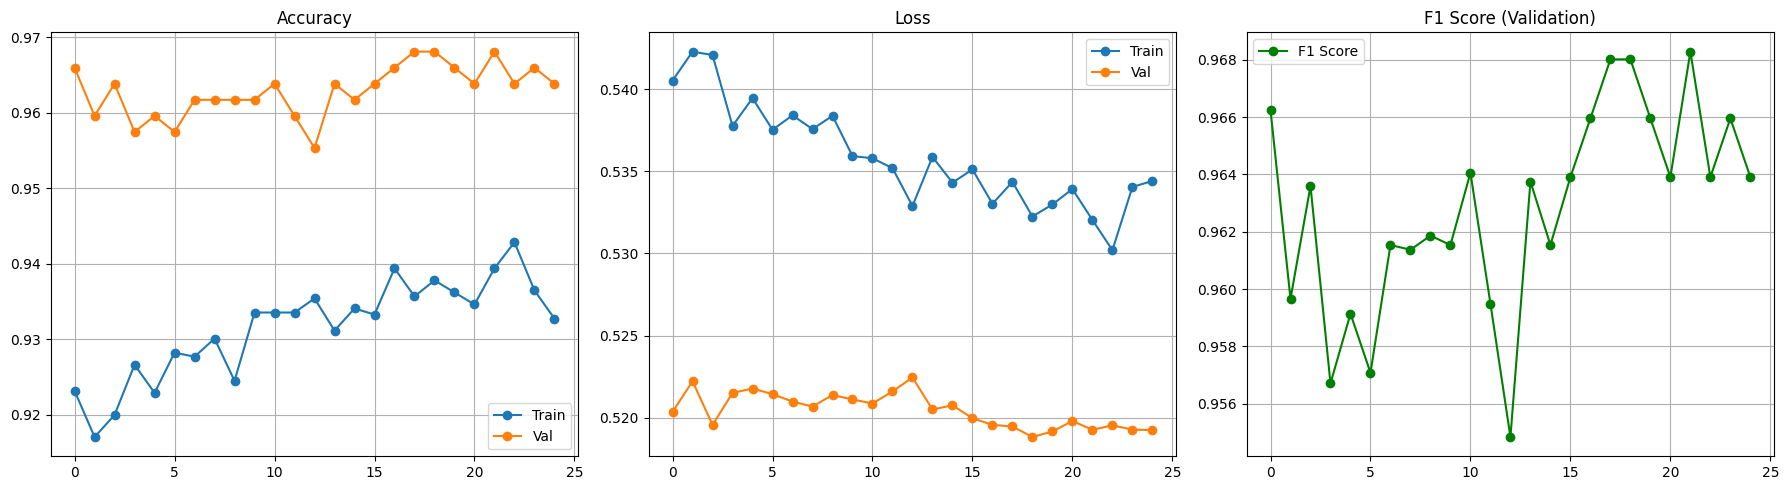

In [74]:
# Cell 7 - גרפים
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history['train_acc'], label='Train', marker='o')
axes[0].plot(history['val_acc'],   label='Val',   marker='o')
axes[0].set_title('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history['train_loss'], label='Train', marker='o')
axes[1].plot(history['val_loss'],   label='Val',   marker='o')
axes[1].set_title('Loss')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(history['val_f1'], label='F1 Score', marker='o', color='green')
axes[2].set_title('F1 Score (Validation)')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'training_history.png'))
plt.show()

דוח ביצועים מלא - Test Set
              precision    recall  f1-score   support

    שגרה (0)       0.92      0.97      0.94       236
  אלימות (1)       0.96      0.91      0.94       235

    accuracy                           0.94       471
   macro avg       0.94      0.94      0.94       471
weighted avg       0.94      0.94      0.94       471

AUC-ROC: 0.9756


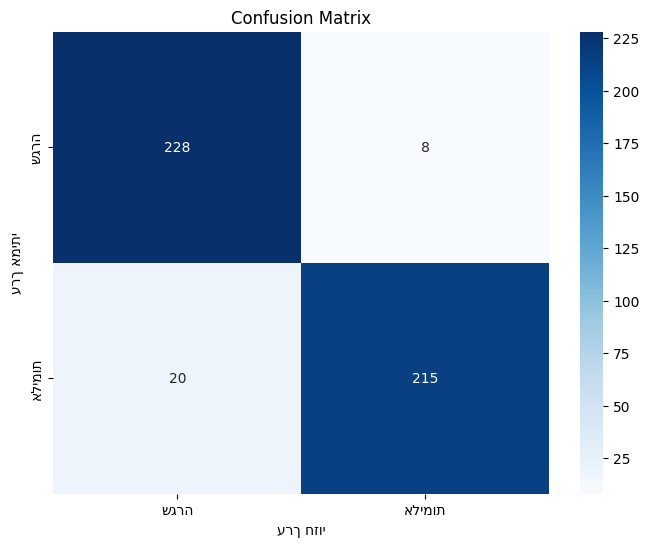

In [9]:
# Cell 8 - דוח ביצועים מלא על Test Set
model.load_state_dict(torch.load(os.path.join(save_dir, 'best_model_mvit.pth')))
model.eval()

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for frames, labels in test_loader:
        frames = frames.to(device)
        labels = labels.to(device)
        outputs   = model(frames)
        predicted = (outputs > 0.5).float()
        all_preds.append(predicted.cpu())
        all_labels.append(labels.cpu())
        all_probs.append(outputs.cpu())

all_preds  = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()
all_probs  = torch.cat(all_probs).numpy()

print('=' * 50)
print('דוח ביצועים מלא - Test Set')
print('=' * 50)
print(classification_report(all_labels, all_preds, target_names=['שגרה (0)', 'אלימות (1)']))
print(f'AUC-ROC: {roc_auc_score(all_labels, all_probs):.4f}')

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['שגרה', 'אלימות'],
            yticklabels=['שגרה', 'אלימות'])
plt.title('Confusion Matrix')
plt.ylabel('ערך אמיתי')
plt.xlabel('ערך חזוי')
plt.savefig(os.path.join(save_dir, 'confusion_matrix.png'))
plt.show()

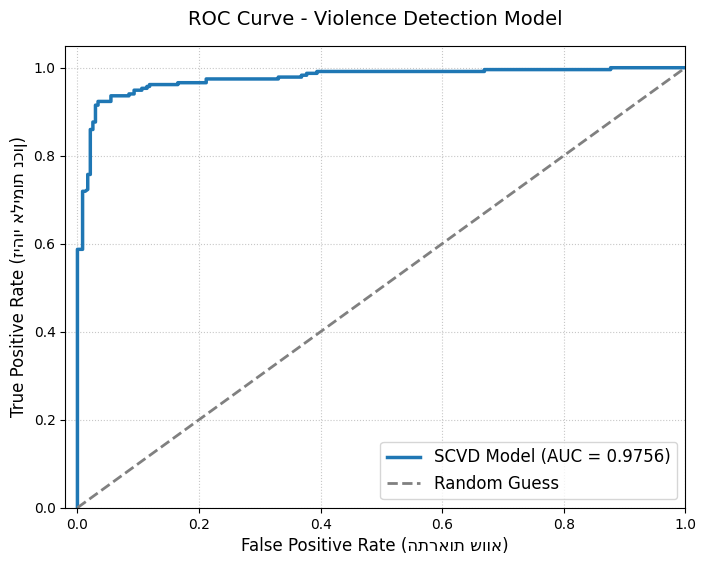

✅ בוצע! הגרף נשמר בהצלחה בנתיב: 
C:\Users\User\Desktop\מיכאל\trained_model_mvit\roc_curve.png


In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import torch
import numpy as np
import os

# 1. איסוף כל התוצאות מסט הבדיקה (Test Set) למערך אחד
try:
    # חיבור רשימות הטנזורים למערך Numpy פשוט
    y_true = torch.cat(all_labels).numpy()
    y_scores = torch.cat(all_probs).numpy()
except TypeError:
    # מקרה גיבוי אם זה כבר הומר למערכים
    y_true = np.array(all_labels).flatten()
    y_scores = np.array(all_probs).flatten()

# 2. חישוב נקודות הגרף והציון המסכם (AUC)
fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

# 3. עיצוב ושרטוט הגרף
plt.figure(figsize=(8, 6))

# שרטוט קו המודל שלנו
plt.plot(fpr, tpr, color='#1f77b4', lw=2.5, 
         label=f'SCVD Model (AUC = {roc_auc:.4f})')

# שרטוט קו האפס (ניחוש אקראי) להשוואה
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Guess')

# עיצוב גבולות, כותרות ורשת
plt.xlim([-0.02, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (התראות שווא)', fontsize=12)
plt.ylabel('True Positive Rate (זיהוי אלימות נכון)', fontsize=12)
plt.title('ROC Curve - Violence Detection Model', fontsize=14, pad=15)
plt.legend(loc="lower right", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)

# 4. שמירת התמונה באיכות גבוהה בנתיב הספציפי
save_dir = r'C:\Users\User\Desktop\מיכאל\trained_model_mvit'
output_filename = os.path.join(save_dir, 'roc_curve.png')

plt.savefig(output_filename, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ בוצע! הגרף נשמר בהצלחה בנתיב: \n{output_filename}")

In [ ]:
# Cell 9 - חיזוי סרטון בודד
def predict_video(video_path, threshold=0.5):
    model.load_state_dict(torch.load(os.path.join(save_dir, 'best_model_mvit.pth')))
    model.eval()

    frames = extract_frames(video_path)
    if frames is None:
        print('שגיאה: לא ניתן לקרוא את הסרטון')
        return

    frames = frames.unsqueeze(0).to(device)
    with torch.no_grad():
        prob = model(frames).item()

    label = 'אלימות' if prob > threshold else 'שגרה'
    print(f'סרטון:      {os.path.basename(video_path)}')
    print(f'תוצאה:      {label}')
    print(f'Confidence: {prob:.2%}')
    return prob

# predict_video(r'D:\Downloads\XD_violence\test\Fighting\example.avi')

In [8]:
# Cell 9 - מיון אוטומטי של סרטונים חדשים (Pseudo-Labeling)
import os
import shutil
import torch
import cv2

# ==========================================
# 1. הגדרות נתיבים - שנה את הנתיב הראשון!
# ==========================================
# התיקייה שבה נמצאים 15,000 הסרטונים הלא ממוינים שלך
unlabeled_data_dir = r'C:\Users\User\Desktop\מיכאל\unlabeled_videos' 

# תיקיית הבסיס שאליה ימוינו הסרטונים
base_sort_dir = r'C:\Users\User\Desktop\מיכאל\sorted_data_fighting'

auto_fight_dir = os.path.join(base_sort_dir, 'Auto_Fight')
auto_nonfight_dir = os.path.join(base_sort_dir, 'Auto_NonFight')
review_dir = os.path.join(base_sort_dir, 'Needs_Review')

# יצירת התיקיות במחשב (אם לא קיימות)
for d in [auto_fight_dir, auto_nonfight_dir, review_dir]:
    os.makedirs(d, exist_ok=True)

# ==========================================
# 2. הגדרת רמות ביטחון (Confidence)
# ==========================================
CONFIDENCE_FIGHT = 0.98    # מעל 98% = ימוין כאלימות
CONFIDENCE_NONFIGHT = 0.02 # מתחת ל-2% = ימוין כשגרה

# ==========================================
# 3. הכנת המודל ופונקציית הקריאה
# ==========================================
# טעינת המשקולות הטובות ביותר מהאימון הקודם
model_path = r'C:\Users\User\Desktop\מיכאל\trained_model_mvit\best_model_mvit.pth'
model.load_state_dict(torch.load(model_path))
model.eval()

# פונקציה לשליפת פריימים מסרטון בודד והכנתם למודל
def get_video_tensor(video_path, num_frames=16):
    frames = []
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total <= 0:
        cap.release()
        return None
    
    skip = max(int(total / num_frames), 1)
    for i in range(num_frames):
        cap.set(cv2.CAP_PROP_POS_FRAMES, i * skip)
        ret, frame = cap.read()
        if not ret: break
        
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = val_transform(frame) # שימוש בטרנספורמציה הרגילה (ללא Augmentation)
        frames.append(frame)
    cap.release()
    
    # השלמת פריימים אם הסרטון קצר מדי
    while len(frames) < num_frames:
        frames.append(frames[-1] if frames else torch.zeros(3, 224, 224))
        
    frames_tensor = torch.stack(frames)
    frames_tensor = frames_tensor.permute(1, 0, 2, 3) # סידור מימדים ל-PyTorch
    return frames_tensor.unsqueeze(0) # הוספת מימד Batch בגודל 1

# ==========================================
# 4. לולאת המיון בפועל
# ==========================================
print("מתחיל במיון האוטומטי...")

processed = 0
moved_fight = 0
moved_nonfight = 0
needs_review = 0

with torch.no_grad():
    for filename in os.listdir(unlabeled_data_dir):
        if not filename.lower().endswith(('.avi', '.mp4', '.mov')): 
            continue
            
        video_path = os.path.join(unlabeled_data_dir, filename)
        
        # הוצאת פריימים והעברה ל-GPU
        frames = get_video_tensor(video_path)
        if frames is None:
            print(f"שגיאה בקריאת הסרטון: {filename}")
            continue
            
        frames = frames.to(device)
        
        # המודל מנחש!
        prob = model(frames).item()
        
        # החלטה לאן להעביר את הסרטון
        if prob >= CONFIDENCE_FIGHT:
            dest_dir = auto_fight_dir
            moved_fight += 1
        elif prob <= CONFIDENCE_NONFIGHT:
            dest_dir = auto_nonfight_dir
            moved_nonfight += 1
        else:
            dest_dir = review_dir
            needs_review += 1
            
        # הזזת הקובץ פיזית לתיקייה החדשה
        shutil.move(video_path, os.path.join(dest_dir, filename))
        
        processed += 1
        # עדכון סטטוס כל 100 סרטונים
        if processed % 100 == 0:
            print(f"עובדו ומוינו {processed} סרטונים...")

print("\n" + "="*40)
print("סיום מיון 15,000 הסרטונים!")
print("="*40)
print(f"סה\"כ עובדו: {processed}")
print(f"✅ תויגו אוטומטית כאלימות: {moved_fight}")
print(f"✅ תויגו אוטומטית כשגרה: {moved_nonfight}")
print(f"⚠️ נשלחו לבדיקה ידנית: {needs_review}")

מתחיל במיון האוטומטי...

סיום מיון 15,000 הסרטונים!
סה"כ עובדו: 41
✅ תויגו אוטומטית כאלימות: 20
✅ תויגו אוטומטית כשגרה: 19
⚠️ נשלחו לבדיקה ידנית: 2


In [65]:
import os
import subprocess
from imageio_ffmpeg import get_ffmpeg_exe

# ==========================================
# 1. הגדרות החיתוך (שדרוג: חיתוך מרובה!)
# ==========================================
video_path = r"C:\Users\User\Desktop\מיכאל\SCVD\SCVD_converted\Train\Normal\n113_converted.avi"

# רשימה של שניות ההתחלה. 
# אם יש לך סרטון של 10 שניות, תכתוב פה [0, 5]. 
# הקוד יחתוך פעם אחת משנייה 0, ופעם שנייה משנייה 5!
start_times = [0, 4] # <--- שדרוג: אפשר להוסיף כמה שניות התחלה שרוצים!

duration = 5 # אורך כל חיתוך יישאר 5 שניות

# ==========================================
# 2. פעולת החיתוך (הלולאה החכמה)
# ==========================================
source_dir = os.path.dirname(video_path)
video_filename = os.path.basename(video_path)
output_folder = os.path.join(source_dir, "5SECCUT")
os.makedirs(output_folder, exist_ok=True)

print(f"📁 התיקייה מוכנה: {output_folder}")
ffmpeg_exe = get_ffmpeg_exe()

# כאן הקסם קורה: לולאה שעוברת על כל נקודות ההתחלה שביקשת
for start_time in start_times:
    end_time = start_time + duration
    
    # השדרוג: שם דינמי שכולל את השניות כדי שלא תהיה דריסה!
    # למשל: cut_0_to_5_video.avi
    new_filename = f"cut_{start_time}_to_{end_time}_{video_filename}"
    output_path = os.path.join(output_folder, new_filename)
    
    print(f"✂️ חותך קטע: משנייה {start_time} עד {end_time}...")
    
    command = [
        ffmpeg_exe, 
        "-y",                   
        "-ss", str(start_time), 
        "-i", video_path,       
        "-t", str(duration),    
        "-c", "copy",           
        output_path             
    ]

    try:
        subprocess.run(command, check=True, capture_output=True, text=True, encoding='utf-8')
        print(f"✅ נשמר בהצלחה: {new_filename}")
    except subprocess.CalledProcessError as e:
        print(f"❌ שגיאה בחיתוך הקטע {start_time}-{end_time}! המנוע דיווח:")
        print(e.stderr)

print("🎉 סיום התהליך! כל החלקים נחתכו.")

📁 התיקייה מוכנה: C:\Users\User\Desktop\מיכאל\SCVD\SCVD_converted\Train\Normal\5SECCUT
✂️ חותך קטע: משנייה 0 עד 5...
✅ נשמר בהצלחה: cut_0_to_5_n113_converted.avi
✂️ חותך קטע: משנייה 4 עד 9...
✅ נשמר בהצלחה: cut_4_to_9_n113_converted.avi
🎉 סיום התהליך! כל החלקים נחתכו.
